In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("data/Salary Data.csv")

df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [6]:
df.shape

(375, 6)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    object 
 2   Education Level      373 non-null    object 
 3   Job Title            373 non-null    object 
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), object(3)
memory usage: 17.7+ KB


In [8]:
df.describe()

,Age,Years of Experience,Salary
count,373.000000,373.000000,373.000000
mean,37.431635,10.030831,100577.345845
std,7.069073,6.557007,48240.013482
min,23.000000,0.000000,350.000000
25%,31.000000,4.000000,55000.000000
50%,36.000000,9.000000,95000.000000
75%,44.000000,15.000000,140000.000000
max,53.000000,25.000000,250000.000000


In [9]:
df.isnull().sum()

Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(50)

In [11]:
print(df["Gender"].unique())
print(df["Education Level"].unique())

['Male' 'Female' nan]
["Bachelor's" "Master's" 'PhD' nan]


In [12]:
print("Number of job titles:", df["Job Title"].nunique())

Number of job titles: 174


In [13]:
df[df.isnull().any(axis=1)]

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
172,NaN,NaN,NaN,NaN,NaN,NaN
260,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
df[df.duplicated(keep=False)].sort_values(
    by=["Age", "Gender", "Job Title"]
)

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
140,28.0,Male,Bachelor's,Junior Business Analyst,2.0,40000.0
195,28.0,Male,Bachelor's,Junior Business Analyst,2.0,40000.0
212,28.0,Male,Bachelor's,Junior Business Development Associate,2.0,40000.0
253,28.0,Male,Bachelor's,Junior Business Development Associate,2.0,40000.0
283,29.0,Female,Bachelor's,Junior Business Development Associate,1.5,35000.0
...,...,...,...,...,...,...
306,49.0,Female,Master's,Director of Marketing,21.0,180000.0
217,50.0,Female,PhD,Director of Operations,22.0,180000.0
258,50.0,Female,PhD,Director of Operations,22.0,180000.0
172,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
df[df["Salary"] < 10000]

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
259,29.0,Male,Bachelor's,Junior Business Operations Analyst,1.5,350.0


In [16]:
df.sort_values("Salary").head(10)

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
259,29.0,Male,Bachelor's,Junior Business Operations Analyst,1.5,350.0
82,25.0,Male,Bachelor's,Sales Representative,0.0,30000.0
283,29.0,Female,Bachelor's,Junior Business Development Associate,1.5,35000.0
348,28.0,Female,Bachelor's,Junior Operations Manager,1.0,35000.0
189,28.0,Male,Bachelor's,Junior Operations Analyst,1.5,35000.0
153,26.0,Male,Bachelor's,Junior Customer Support Specialist,2.0,35000.0
165,27.0,Male,Bachelor's,Junior Business Development Associate,1.5,35000.0
218,29.0,Male,Bachelor's,Junior Business Operations Analyst,1.5,35000.0
310,29.0,Female,Bachelor's,Junior Business Development Associate,1.5,35000.0
134,27.0,Male,Bachelor's,Junior Sales Representative,1.0,35000.0


In [17]:
df = df.dropna(how="all")
df.shape

(373, 6)

In [18]:
df = df.dropna()

In [19]:
df=df.drop_duplicates()

In [20]:
df = df[df["Salary"] >= 10000]
print("Shape after removing suspicious salaries:", df.shape)

Shape after removing suspicious salaries: (323, 6)


In [21]:
print(df.shape)
print(df.isnull().sum())
print(df.duplicated().sum())

(323, 6)
Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64
0


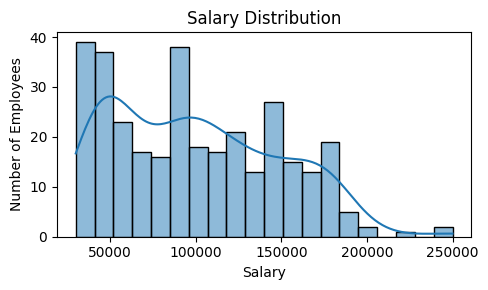

In [22]:
plt.figure(figsize=(5, 3))
plt.tight_layout()
sns.histplot(df["Salary"], bins=20, kde=True)

plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Number of Employees")
plt.tight_layout()
plt.show()

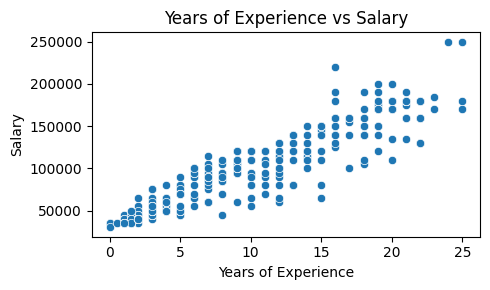

In [23]:
plt.figure(figsize=(5, 3))

sns.scatterplot(
    data=df,
    x="Years of Experience",
    y="Salary"
)

plt.title("Years of Experience vs Salary")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.tight_layout()
plt.show()

In [24]:
df[["Age", "Years of Experience", "Salary"]].corr()

,Age,Years of Experience,Salary
Age,1.000000,0.979116,0.917042
Years of Experience,0.979116,1.000000,0.924677
Salary,0.917042,0.924677,1.000000


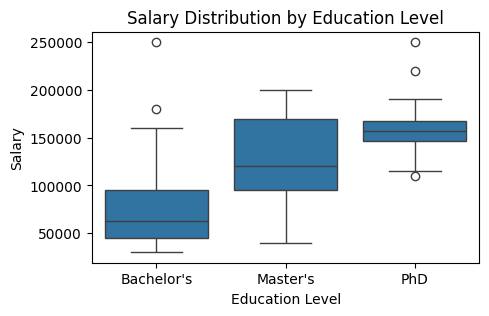

In [25]:
plt.figure(figsize=(5, 3))

sns.boxplot(
    data=df,
    x="Education Level",
    y="Salary"
)

plt.title("Salary Distribution by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Salary")

plt.show()

In [26]:
X = df.drop("Salary", axis=1)
y = df["Salary"]

In [27]:
print("Features:")
print(X.head())

Features:
    Age  Gender Education Level          Job Title  Years of Experience
0  32.0    Male      Bachelor's  Software Engineer                  5.0
1  28.0  Female        Master's       Data Analyst                  3.0
2  45.0    Male             PhD     Senior Manager                 15.0
3  36.0  Female      Bachelor's    Sales Associate                  7.0
4  52.0    Male        Master's           Director                 20.0


In [28]:
print("\nTarget:")
print(y.head())


Target:
0     90000.0
1     65000.0
2    150000.0
3     60000.0
4    200000.0
Name: Salary, dtype: float64


In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [30]:
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 258
Testing samples: 65


In [31]:
numeric_features = [
    "Age",
    "Years of Experience"
]

categorical_features = [
    "Gender",
    "Education Level",
    "Job Title"
]

In [32]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

In [33]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

In [39]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

In [35]:
models = {
    "Linear_Regression_Model": LinearRegression(),
    "Random_Forest_Regressor_Model": RandomForestRegressor(random_state=42, n_jobs=-1,n_estimators=200),
    "K_Neighbors_Regressor_Model": KNeighborsRegressor(),
    "Support_Vector_Regressor_Model": SVR(),
    "Gradient_Boosting_Regressor_Model": GradientBoostingRegressor(random_state=42),
    "Decision_Tree_Regressor_Model": DecisionTreeRegressor(random_state=42),
    "XGBoost_Regressor_Model": XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1)
}

In [36]:
pipelines = {}

for name, model in models.items():

    pipelines[name] = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

In [37]:
pipelines = {}

for name, model in models.items():

    pipelines[name] = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

In [40]:
results = []

for name, pipeline in pipelines.items():

    pipeline.fit(X_train, y_train)

    predictions = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    })

In [41]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    by="R²",
    ascending=False
)

,Model,MAE,RMSE,R²
2,K_Neighbors_Regressor_Model,10676.923077,14388.029212,0.894126
4,Gradient_Boosting_Regressor_Model,11070.457607,15052.038594,0.884128
1,Random_Forest_Regressor_Model,10583.230769,15279.490947,0.880600
0,Linear_Regression_Model,12547.726787,16176.852090,0.866164
6,XGBoost_Regressor_Model,11072.024880,16644.958122,0.858306
5,Decision_Tree_Regressor_Model,13153.846154,21917.678148,0.754317
3,Support_Vector_Regressor_Model,37284.863419,44587.028231,-0.016724


In [56]:
#Since Random Forest Regressor model is the best among these we will use that only and hypertune it
from sklearn.model_selection import GridSearchCV
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                random_state=42
            )
        )
    ]
)
param_grid = {
    "model__n_estimators": [200, 400, 600],
    "model__max_depth": [None, 10, 15, 20],
    "model__min_samples_split": [2, 4],
    "model__min_samples_leaf": [1, 2]
}
grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)
grid_search.fit(X_train, y_train)


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__max_depth': [None, 10, ...], 'model__min_samples_leaf': [1, 2], 'model__min_samples_split': [2, 4], 'model__n_estimators': [200, 400, ...]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [43]:
from sklearn.model_selection import cross_val_score
cv_results = []

for name, pipeline in pipelines.items():

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring="r2"
    )

    cv_results.append({
        "Model": name,
        "Mean R²": scores.mean(),
        "Std R²": scores.std()
    })
cv_results_df = pd.DataFrame(cv_results)

cv_results_df = cv_results_df.sort_values(
    by="Mean R²",
    ascending=False
)

cv_results_df

,Model,Mean R²,Std R²
4,Gradient_Boosting_Regressor_Model,0.875910,0.032143
1,Random_Forest_Regressor_Model,0.872962,0.028989
2,K_Neighbors_Regressor_Model,0.869565,0.023037
6,XGBoost_Regressor_Model,0.867327,0.033631
0,Linear_Regression_Model,0.829241,0.026894
5,Decision_Tree_Regressor_Model,0.812185,0.073159
3,Support_Vector_Regressor_Model,-0.025340,0.028690


In [44]:
final_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=300,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)
final_model.fit(X_train, y_train)
final_predictions = final_model.predict(X_test)


In [45]:
final_mae = mean_absolute_error(
    y_test,
    final_predictions
)

final_rmse = np.sqrt(
    mean_squared_error(y_test, final_predictions)
)

final_r2 = r2_score(
    y_test,
    final_predictions
)

print("Final Random Forest")
print("-------------------")
print("MAE :", final_mae)
print("RMSE:", final_rmse)
print("R²  :", final_r2)

Final Random Forest
-------------------
MAE : 10562.17094017094
RMSE: 15222.268516368558
R²  : 0.8814927384971587


In [46]:
import joblib

joblib.dump(
    final_model,
    "salary_prediction_pipeline.pkl"
)

print("Model pipeline saved successfully.")

Model pipeline saved successfully.


In [47]:
loaded_model = joblib.load(
    "salary_prediction_pipeline.pkl"
)

print("Model loaded successfully.")

Model loaded successfully.


In [48]:
loaded_predictions = loaded_model.predict(X_test)

print("Original prediction:", final_predictions[0])
print("Loaded prediction: ", loaded_predictions[0])

Original prediction: 42766.666666666664
Loaded prediction:  42766.666666666664


In [49]:
new_employee = pd.DataFrame({
    "Age": [30],
    "Gender": ["Male"],
    "Education Level": ["Bachelor's"],
    "Job Title": ["Software Engineer"],
    "Years of Experience": [5]
})
predicted_salary = loaded_model.predict(new_employee)[0]

print(f"Predicted Salary: ${predicted_salary:,.2f}")

Predicted Salary: $65,433.33


In [50]:
preprocessor_fitted = final_model.named_steps["preprocessor"]

feature_names = preprocessor_fitted.get_feature_names_out()

importances = final_model.named_steps["model"].feature_importances_
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})
feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)
feature_importance_df.head(20)

,Feature,Importance
1,num__Years of Experience,0.505024
0,num__Age,0.394001
4,cat__Education Level_Bachelor's,0.023122
13,cat__Job Title_Chief Data Officer,0.006275
8,cat__Job Title_Administrative Assistant,0.005813
6,cat__Education Level_PhD,0.004745
5,cat__Education Level_Master's,0.003750
12,cat__Job Title_CEO,0.003601
136,cat__Job Title_Senior Project Manager,0.003193
14,cat__Job Title_Chief Technology Officer,0.003015


In [52]:
# Copy the feature importance data
importance = feature_importance_df.copy()

# Map encoded features back to their original feature groups
def get_original_feature(feature):
    if feature.startswith("num__"):
        return feature.replace("num__", "")
    
    elif feature.startswith("cat__"):
        feature = feature.replace("cat__", "")
        
        if feature.startswith("Gender_"):
            return "Gender"
        elif feature.startswith("Education Level_"):
            return "Education Level"
        elif feature.startswith("Job Title_"):
            return "Job Title"
    
    return feature


importance["Original Feature"] = (
    importance["Feature"].apply(get_original_feature)
)
grouped_importance = (
    importance
    .groupby("Original Feature")["Importance"]
    .sum()
    .sort_values(ascending=False)
)

grouped_importance

Original Feature
Years of Experience    0.505024
Age                    0.394001
Job Title              0.066413
Education Level        0.031617
Gender                 0.002946
Name: Importance, dtype: float64

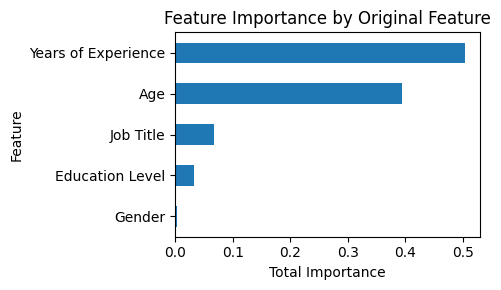

In [53]:
plt.figure(figsize=(5, 3))

grouped_importance.sort_values().plot(
    kind="barh"
)

plt.title("Feature Importance by Original Feature")
plt.xlabel("Total Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

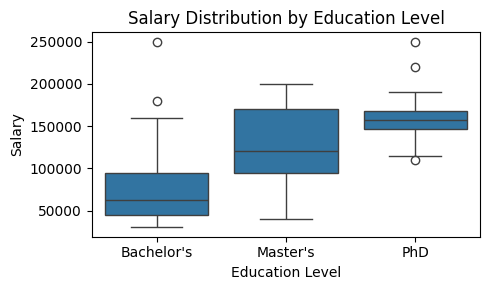

In [54]:
plt.figure(figsize=(5, 3))

sns.boxplot(
    data=df,
    x="Education Level",
    y="Salary"
)

plt.title("Salary Distribution by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Salary")

plt.tight_layout()
plt.show()

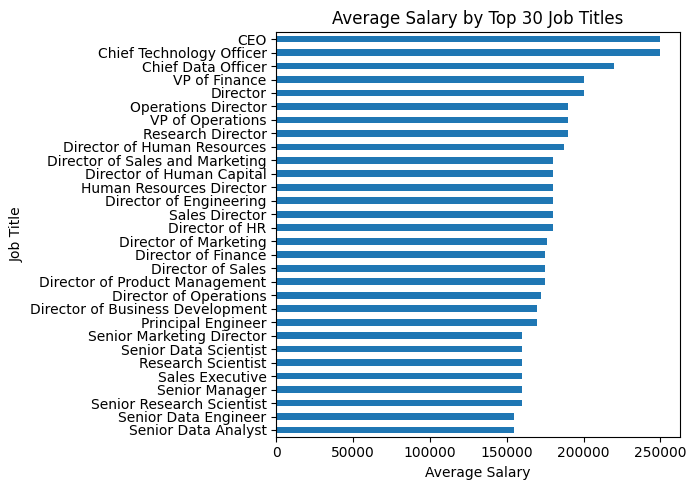

In [55]:
job_salary = (
    df.groupby("Job Title")["Salary"]
      .mean()
      .sort_values(ascending=False)
      .head(30)
)
plt.figure(figsize=(7, 5))

job_salary.sort_values().plot(
    kind="barh"
)

plt.title("Average Salary by Top 30 Job Titles")
plt.xlabel("Average Salary")
plt.ylabel("Job Title")

plt.tight_layout()
plt.show()


In [57]:
feature_importance_df.to_csv(
    "feature_importance.csv",
    index=False
)
grouped_importance.to_csv(
    "grouped_feature_importance.csv"
)